In [1]:
# installing required packages
!pip install imbalanced-learn shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score, roc_auc_score, roc_curve, confusion_matrix,classification_report)
from imblearn.over_sampling import SMOTE
import shap

# now first we load the credit card dataset
# this csv file uses semicolons instead of commas (european format)
filepath = '/content/Credit_Card.csv'
print(f"Loading dataset from {filepath}")
raw_df = pd.read_csv(filepath, sep=';', low_memory=False,on_bad_lines='skip', encoding='utf-8-sig')

print(f"Loaded successfully — {raw_df.shape[0]} rows, {raw_df.shape[1]} columns")
print(f"\nColumn list: {raw_df.columns.tolist()}")
print(f"\nDatatypes:\n{raw_df.dtypes}")
raw_df.head()


Loading dataset from /content/Credit_Card.csv
Loaded successfully — 34788 rows, 30 columns

Column list: ['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default.payment.next.month', 'risk_leak', 'BILL_AMT_SUM', 'LIMIT_BAL_LOG', 'CITY', 'RISK_RATING']

Datatypes:
ID                              int64
LIMIT_BAL                     float64
SEX                           float64
EDUCATION                     float64
MARRIAGE                      float64
AGE                           float64
PAY_0                           int64
PAY_2                           int64
PAY_3                           int64
PAY_4                           int64
PAY_5                           int64
PAY_6                           int64
BILL_AMT1                     float64
BILL_AMT2                  

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,risk_leak,BILL_AMT_SUM,LIMIT_BAL_LOG,CITY,RISK_RATING
0,1,20000.0,2.0,2.0,NaN,24.0,2,2,-1,-1,...,0.0,0.0,0.0,0.0,1,1.075.675.276.433.290,7704.0,990.353.755.128.617,City_38,2
1,2,120000.0,2.0,2.0,2.0,26.0,-1,2,0,0,...,1000.0,1000.0,0.0,2000.0,1,10.940.840.854.872.400,17077.0,11.695.255.355.062.700,City_6,1
2,3,90000.0,2.0,2.0,2.0,34.0,0,0,0,0,...,1000.0,1000.0,1000.0,5000.0,0,0.0703022492301175,101653.0,11.407.576.060.361.700,City_20,1
3,4,50000.0,2.0,2.0,1.0,37.0,0,0,0,0,...,1200.0,1100.0,1069.0,1000.0,0,0.058442435467177846,231334.0,10.819.798.284.210.200,City_25,1
4,5,50000.0,1.0,2.0,1.0,57.0,-1,0,-1,0,...,10000.0,9000.0,689.0,679.0,0,0.12943102887089503,109339.0,10.819.798.284.210.200,City_44,1


missing values breakdown:
               count   pct
LIMIT_BAL       1709  4.91
SEX             1767  5.08
EDUCATION       1734  4.98
MARRIAGE        1733  4.98
AGE             1755  5.04
PAY_AMT1        1725  4.96
PAY_AMT2        1744  5.01
LIMIT_BAL_LOG   1709  4.91

Rows with at least 1 missing value: 10491

Fixing risk_leak column formatting...
  NaN after fixing: 31
Recalculating LIMIT_BAL_LOG from LIMIT_BAL...

Filling missing values:
  LIMIT_BAL: 1709 nulls -> filled with median 140000
  AGE: 1755 nulls -> filled with median 34
  PAY_AMT1: 1725 nulls -> filled with median 2160
  PAY_AMT2: 1744 nulls -> filled with median 2019
  SEX: 1767 nulls -> filled with mode 2
  EDUCATION: 1734 nulls -> filled with mode 2
  MARRIAGE: 1733 nulls -> filled with mode 2
  risk_leak: 31 nulls -> filled with median


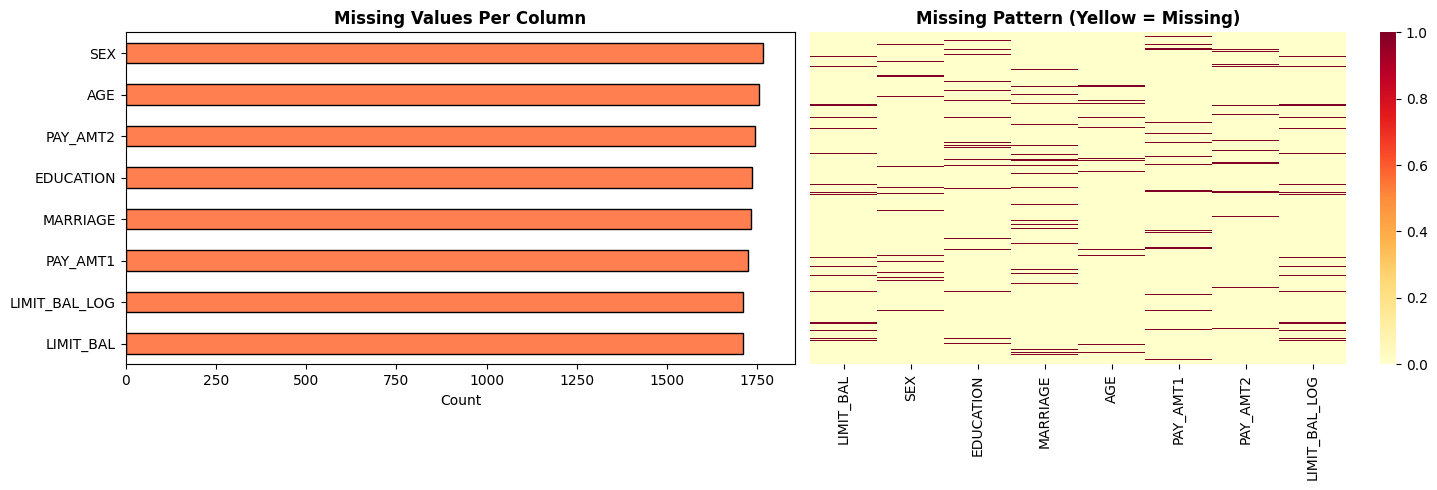


Cleaned shape: (34788, 29)
Any nulls remaining? 0


In [2]:
# Task 1 & 2: Data Cleaning and Preparation

df = raw_df.copy()

# now checking missing values first
print("missing values breakdown:")
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
null_info = pd.DataFrame({'count': null_counts, 'pct': null_pct})
print(null_info[null_info['count'] > 0])
print(f"\nRows with at least 1 missing value: {df.isnull().any(axis=1).sum()}")

# I noticed risk_leak and LIMIT_BAL_LOG have weird formatting
# some values look like "1.075.675.276.433.290" — dots used as thousands separator
# also found scientific notation with commas like "-2,00E+11"
# need to fix these before doing anything else

def fix_risk_leak_format(val):
    """handles the european number formatting mess in risk_leak"""
    txt = str(val).strip()
    if txt == 'nan':
        return np.nan

    num_dots = txt.count('.')
    num_commas = txt.count(',')

    # comma scientific notation like -2,00E+11 is corrupted beyond repair
    if num_commas > 0:
        return np.nan
    # normal float - just convert
    elif num_dots <= 1:
        return float(txt)
    # multiple dots = european thousands separators
    # keep first dot as decimal point, strip the rest
    else:
        dot_pos = txt.index('.')
        integer_part = txt[:dot_pos]
        decimal_part = txt[dot_pos+1:].replace('.', '')
        return float(integer_part + '.' + decimal_part)

print("\nFixing risk_leak column formatting...")
df['risk_leak'] = df['risk_leak'].apply(fix_risk_leak_format)
print(f"  NaN after fixing: {df['risk_leak'].isna().sum()}")

# LIMIT_BAL_LOG has same issue — easier to just recalculate it
print("Recalculating LIMIT_BAL_LOG from LIMIT_BAL...")
df['LIMIT_BAL_LOG'] = np.log(df['LIMIT_BAL'])

# now handle missing values
# using median for numbers (robust to outliers in financial data)
# using mode for categories (keeps the most common value)
print("\nFilling missing values:")

numerical_nulls = ['LIMIT_BAL', 'AGE', 'PAY_AMT1', 'PAY_AMT2']
for c in numerical_nulls:
    n_miss = df[c].isna().sum()
    fill_val = df[c].median()
    df[c] = df[c].fillna(fill_val)
    print(f"  {c}: {n_miss} nulls -> filled with median {fill_val:.0f}")

categorical_nulls = ['SEX', 'EDUCATION', 'MARRIAGE']
for c in categorical_nulls:
    n_miss = df[c].isna().sum()
    fill_val = df[c].mode()[0]
    df[c] = df[c].fillna(fill_val)
    print(f"  {c}: {n_miss} nulls -> filled with mode {fill_val:.0f}")

# fix remaining risk_leak NaNs
rl_miss = df['risk_leak'].isna().sum()
df['risk_leak'] = df['risk_leak'].fillna(df['risk_leak'].median())
print(f"  risk_leak: {rl_miss} nulls -> filled with median")

# recalculate LIMIT_BAL_LOG now that LIMIT_BAL is clean
df['LIMIT_BAL_LOG'] = np.log(df['LIMIT_BAL'])

# dropping ID — not useful for prediction
df.drop(columns=['ID'], inplace=True)

# convert categorical cols to int
df['SEX'] = df['SEX'].astype(int)
df['EDUCATION'] = df['EDUCATION'].astype(int)
df['MARRIAGE'] = df['MARRIAGE'].astype(int)

# missing value visualisation
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
null_info_plot = null_info[null_info['count'] > 0].sort_values('count', ascending=True)
null_info_plot['count'].plot(kind='barh', color='coral', edgecolor='black', ax=axes[0])
axes[0].set_title('Missing Values Per Column', fontweight='bold')
axes[0].set_xlabel('Count')

cols_with_nulls = null_info[null_info['count'] > 0].index.tolist()
if cols_with_nulls:
    sns.heatmap(raw_df[cols_with_nulls].isnull(), cbar=True, yticklabels=False,
                cmap='YlOrRd', ax=axes[1])
    axes[1].set_title('Missing Pattern (Yellow = Missing)', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nCleaned shape: {df.shape}")
print(f"Any nulls remaining? {df.isnull().sum().sum()}")


Target variable distribution:
  Non-default (0): 28132 (80.9%)
  Default (1):     6656 (19.1%)
  Ratio: 4.2 : 1 — clearly imbalanced


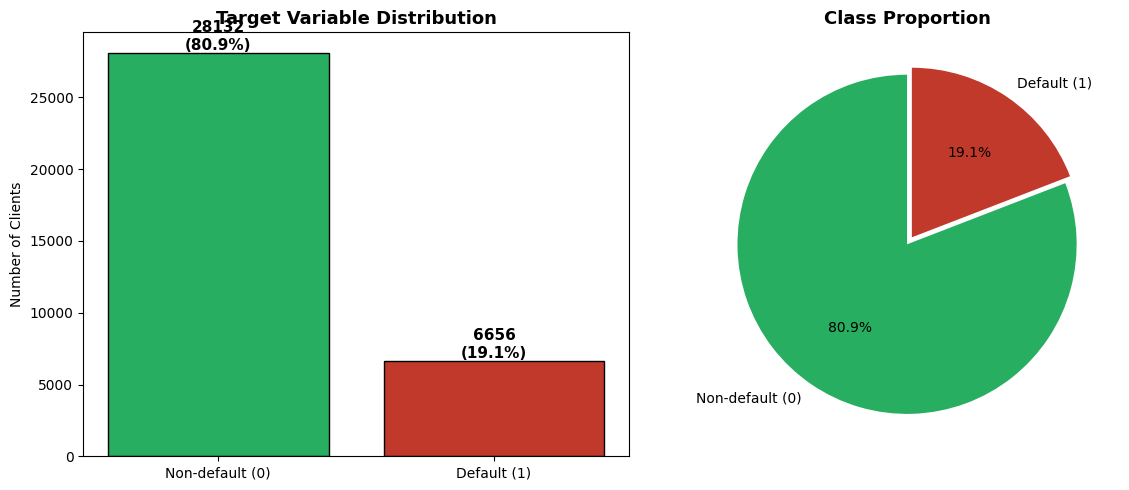


Descriptive Statistics for Key Features:
                    Mean     Median    Std Dev        Min          Max
LIMIT_BAL      182474.58  140000.00  230266.05   10000.00   5600000.00
AGE                35.44      34.00       9.01      21.00        79.00
BILL_AMT_SUM   294815.17  129037.00  571807.25 -336259.00  21292660.00
LIMIT_BAL_LOG      11.71      11.85       0.94       9.21        15.54
risk_leak           1.12       0.03       5.45      -0.39       123.57


In [3]:
# TASK 1: Exploratory Data Analysis

tgt = 'default.payment.next.month'

# checking class distribution
class_counts = df[tgt].value_counts()
print("Target variable distribution:")
print(f"  Non-default (0): {class_counts[0]} ({class_counts[0]/len(df)*100:.1f}%)")
print(f"  Default (1):     {class_counts[1]} ({class_counts[1]/len(df)*100:.1f}%)")
print(f"  Ratio: {class_counts[0]/class_counts[1]:.1f} : 1 — clearly imbalanced")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
bar_labels = ['Non-default (0)', 'Default (1)']
bar_colors = ['#27ae60', '#c0392b']

ax1.bar(bar_labels, class_counts.values, color=bar_colors, edgecolor='black')
for idx, val in enumerate(class_counts.values):
    ax1.text(idx, val + 200, f'{val}\n({val/len(df)*100:.1f}%)',
             ha='center', fontsize=11, fontweight='bold')
ax1.set_title('Target Variable Distribution', fontweight='bold', fontsize=13)
ax1.set_ylabel('Number of Clients')

ax2.pie(class_counts.values, labels=bar_labels, colors=bar_colors,
        autopct='%1.1f%%', startangle=90, explode=(0, 0.05))
ax2.set_title('Class Proportion', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# descriptive statistics for the key numerical columns
important_cols = ['LIMIT_BAL', 'AGE', 'BILL_AMT_SUM', 'LIMIT_BAL_LOG', 'risk_leak']
stat_table = df[important_cols].describe().T[['mean', '50%', 'std', 'min', 'max']]
stat_table.columns = ['Mean', 'Median', 'Std Dev', 'Min', 'Max']
print("\nDescriptive Statistics for Key Features:")
print(stat_table.round(2).to_string())


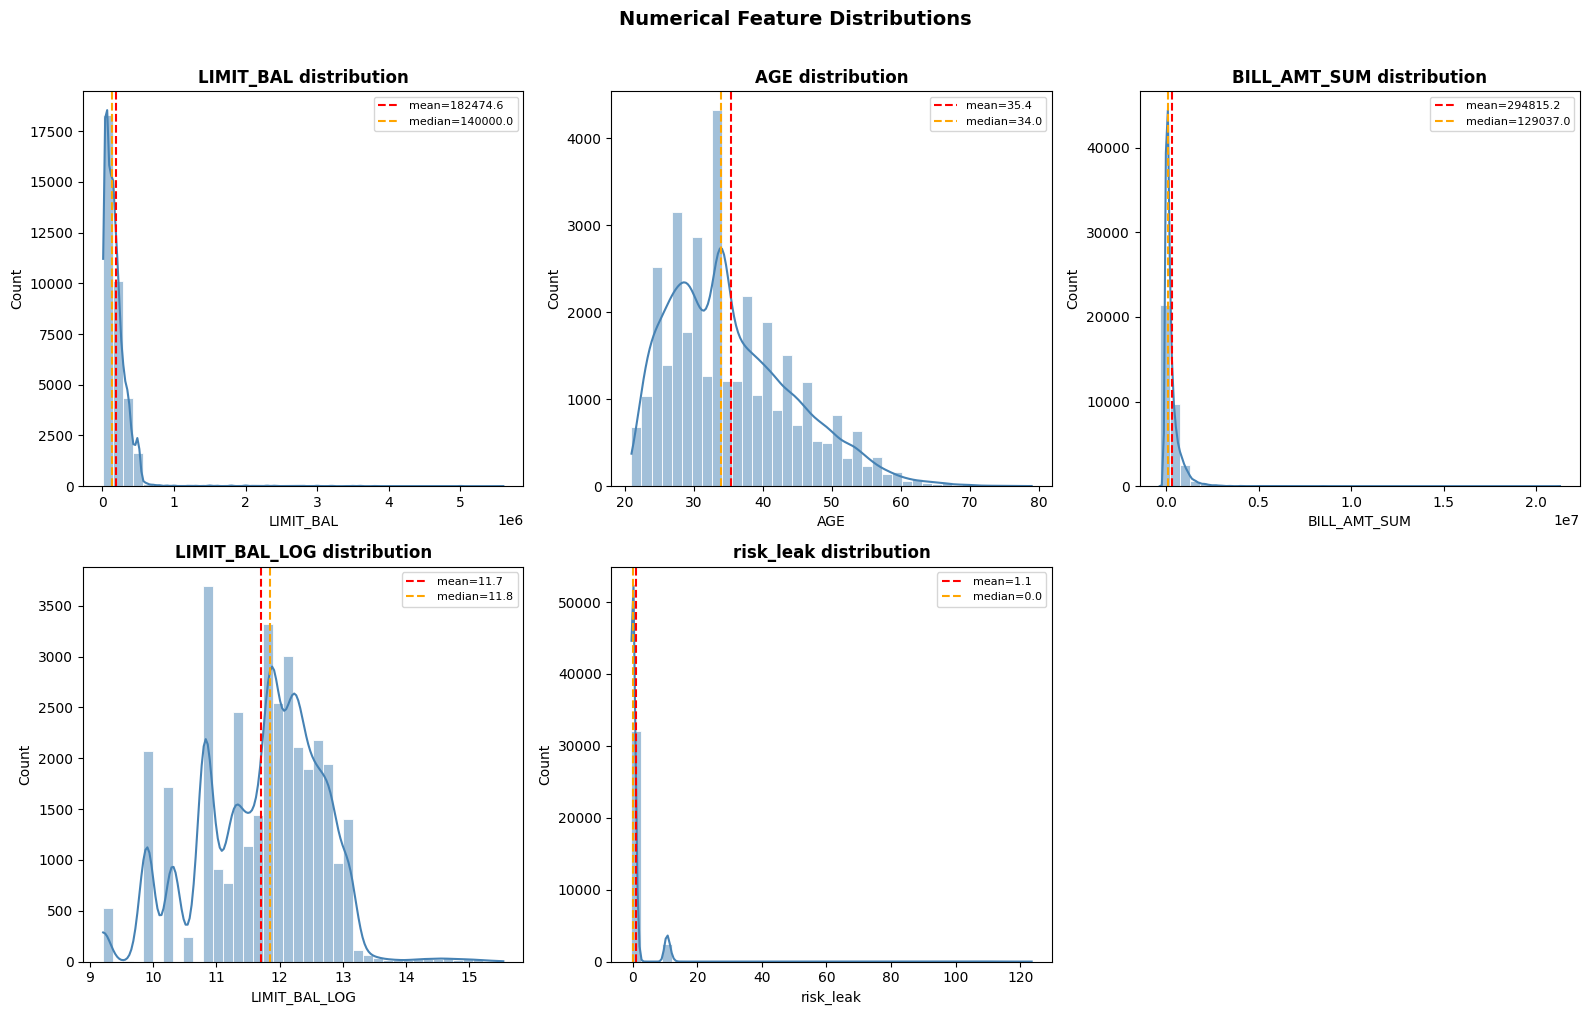

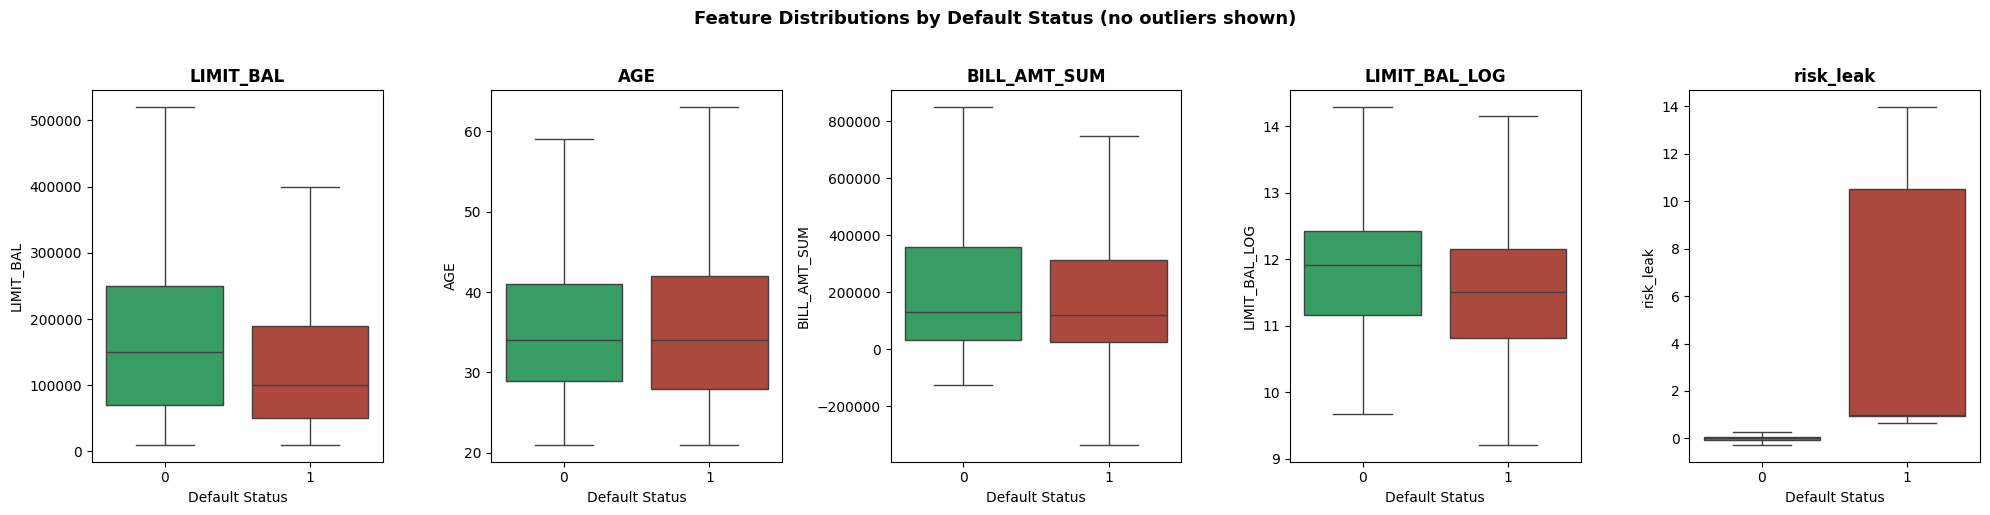

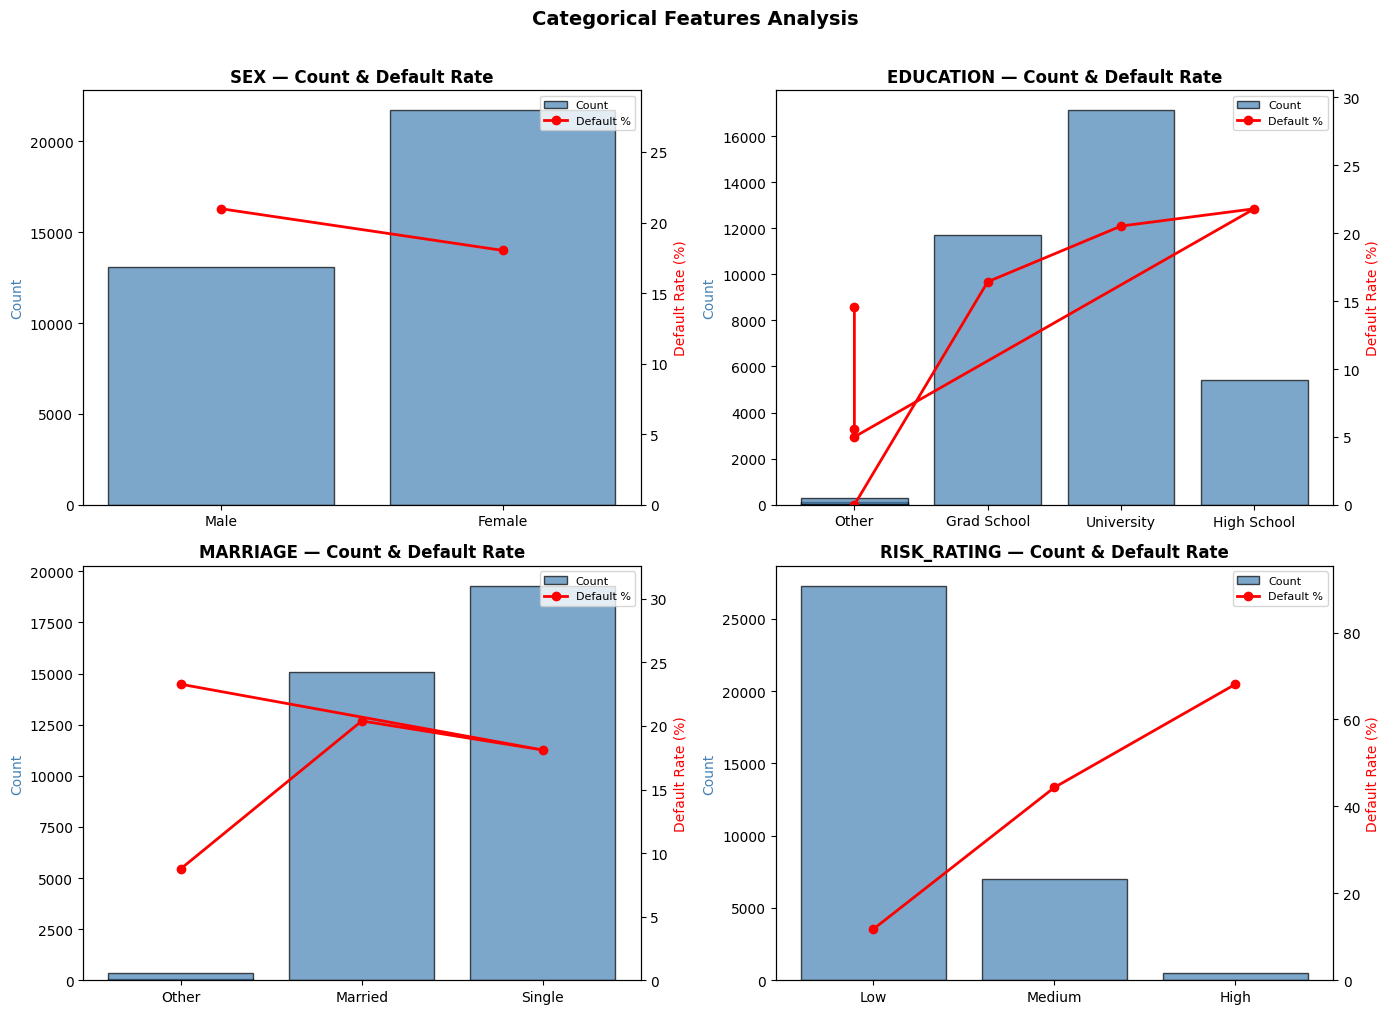

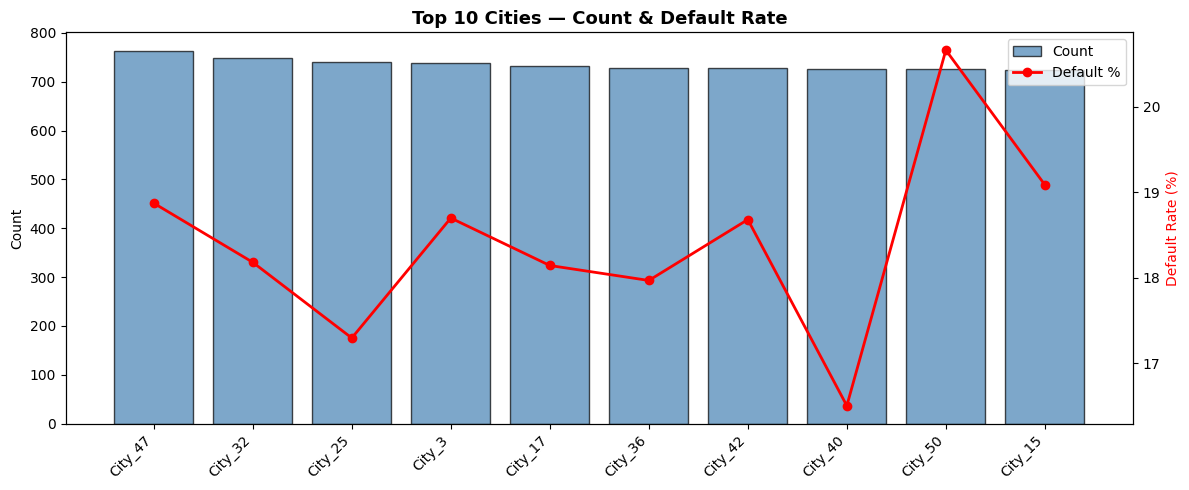

In [4]:
# histograms — checking distributions and skewness
num_cols = ['LIMIT_BAL', 'AGE', 'BILL_AMT_SUM', 'LIMIT_BAL_LOG', 'risk_leak']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes_flat = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, bins=40, ax=axes_flat[i],color='steelblue', edgecolor='white')
    axes_flat[i].set_title(f'{col} distribution', fontweight='bold')
    avg = df[col].mean()
    med = df[col].median()
    axes_flat[i].axvline(avg, color='red', ls='--', label=f'mean={avg:.1f}')
    axes_flat[i].axvline(med, color='orange', ls='--', label=f'median={med:.1f}')
    axes_flat[i].legend(fontsize=8)
axes_flat[5].axis('off')
plt.suptitle('Numerical Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# box plots — comparing default vs non-default groups
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, col in enumerate(num_cols):
    sns.boxplot(x=tgt, y=col, data=df, ax=axes[i],palette=['#27ae60', '#c0392b'], showfliers=False)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Default Status')
plt.suptitle('Feature Distributions by Default Status (no outliers shown)',fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# categoricaal features — how they relate to default rate
cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE', 'RISK_RATING']
cat_names = {
    'SEX': {1: 'Male', 2: 'Female'},
    'EDUCATION': {0: 'Other', 1: 'Grad School', 2: 'University',
                  3: 'High School', 4: 'Other', 5: 'Other', 6: 'Other'},
    'MARRIAGE': {0: 'Other', 1: 'Married', 2: 'Single', 3: 'Other'},
    'RISK_RATING': {1: 'Low', 2: 'Medium', 3: 'High'}
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, col in enumerate(cat_cols):
    ax = axes.flatten()[i]
    grp = df.groupby(col)[tgt].mean().reset_index()
    ct = df[col].value_counts().sort_index().reset_index()
    ct.columns = [col, 'n']
    merged = ct.merge(grp, on=col)
    xlabels = [cat_names[col].get(v, str(v)) for v in merged[col]]

    ax.bar(xlabels, merged['n'], color='steelblue', edgecolor='black', alpha=0.7, label='Count')
    ax.set_ylabel('Count', color='steelblue')
    ax.set_title(f'{col} — Count & Default Rate', fontweight='bold')
    ax_r = ax.twinx()
    ax_r.plot(xlabels, merged[tgt]*100, 'ro-', linewidth=2, label='Default %')
    ax_r.set_ylabel('Default Rate (%)', color='red')
    ax_r.set_ylim(0, max(merged[tgt]*100)*1.4)
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax_r.get_legend_handles_labels()
    ax.legend(h1+h2, l1+l2, loc='upper right', fontsize=8)

plt.suptitle('Categorical Features Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# city analysis — top 10 by count
fig, ax = plt.subplots(figsize=(12, 5))
city_stats = df.groupby('CITY').agg(n=('CITY', 'size'), def_rate=(tgt, 'mean')).sort_values('n', ascending=False).head(10)

xpos = range(len(city_stats))
ax.bar(xpos, city_stats['n'], color='steelblue', edgecolor='black', alpha=0.7, label='Count')
ax.set_xticks(xpos)
ax.set_xticklabels(city_stats.index, rotation=45, ha='right')
ax.set_ylabel('Count')

ax_r = ax.twinx()
ax_r.plot(xpos, city_stats['def_rate']*100, 'ro-', linewidth=2, label='Default %')
ax_r.set_ylabel('Default Rate (%)', color='red')
ax.set_title('Top 10 Cities — Count & Default Rate', fontweight='bold', fontsize=13)
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax_r.get_legend_handles_labels()
ax.legend(h1+h2, l1+l2)
plt.tight_layout()
plt.show()


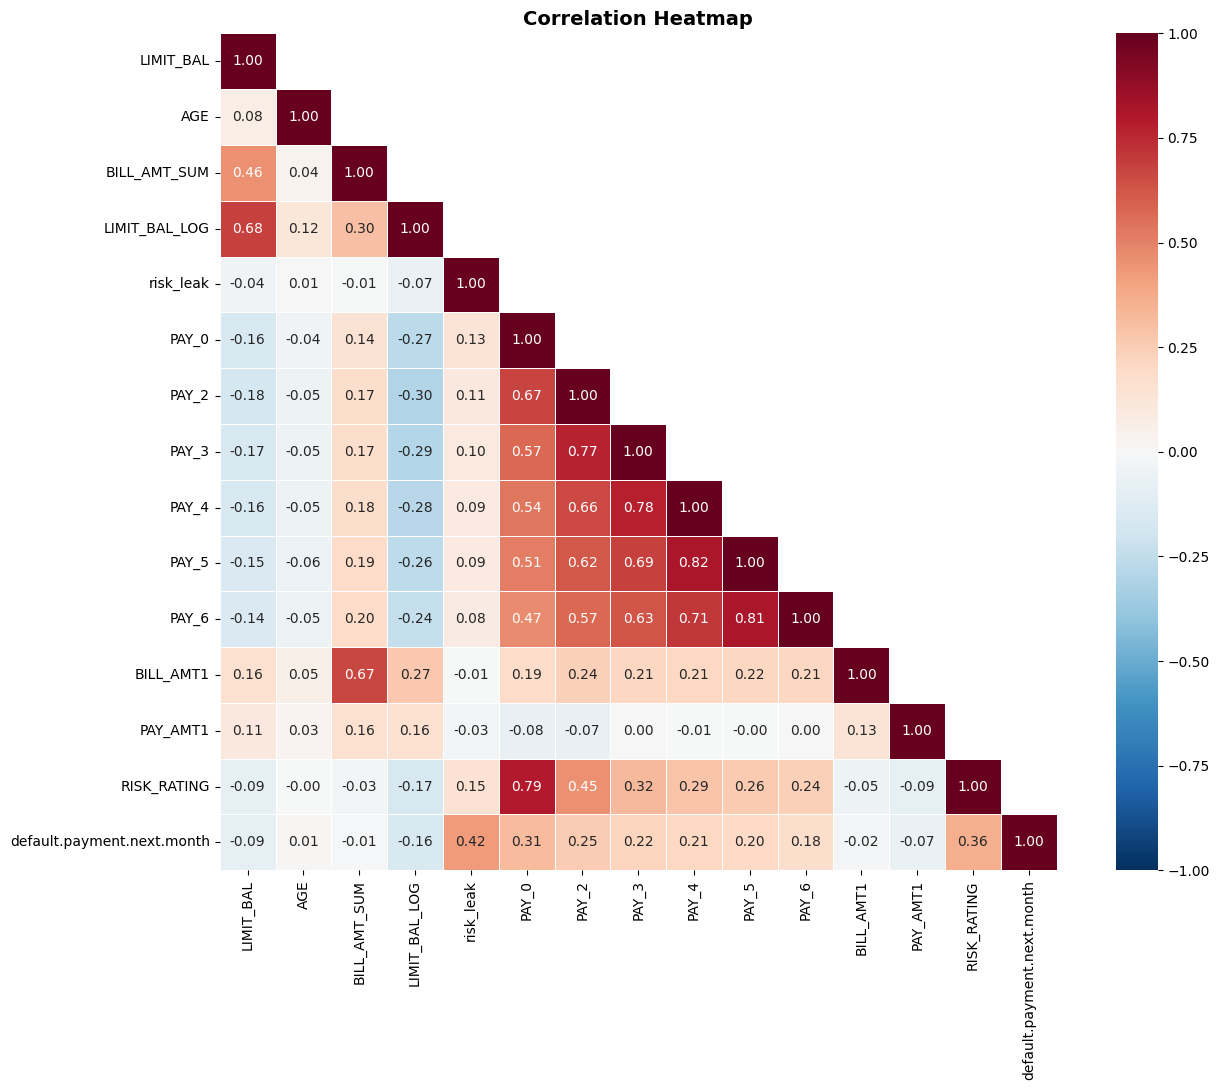

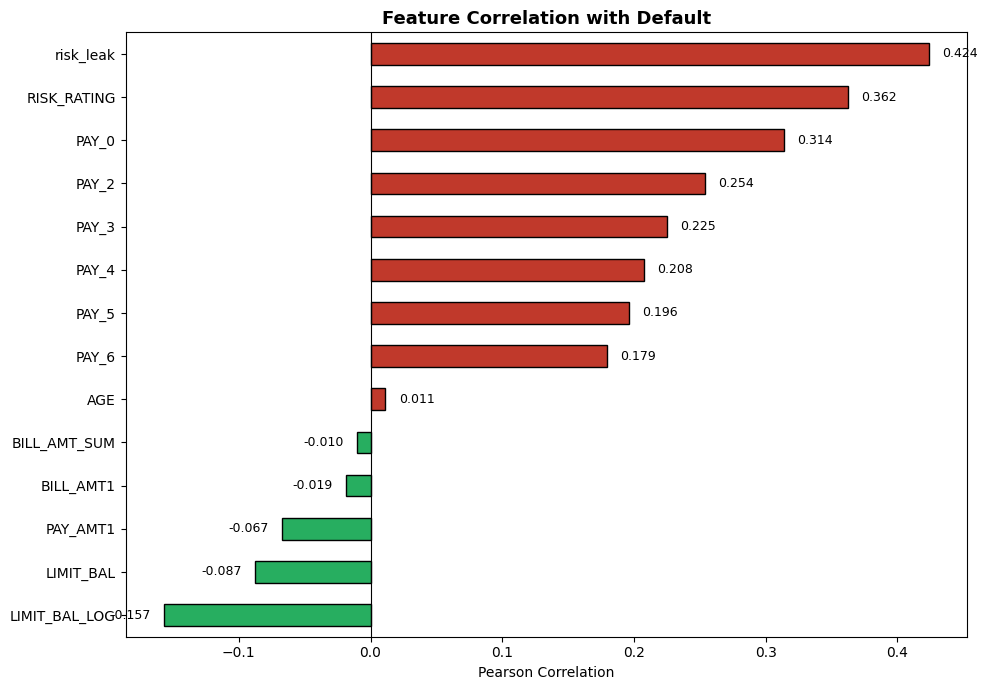

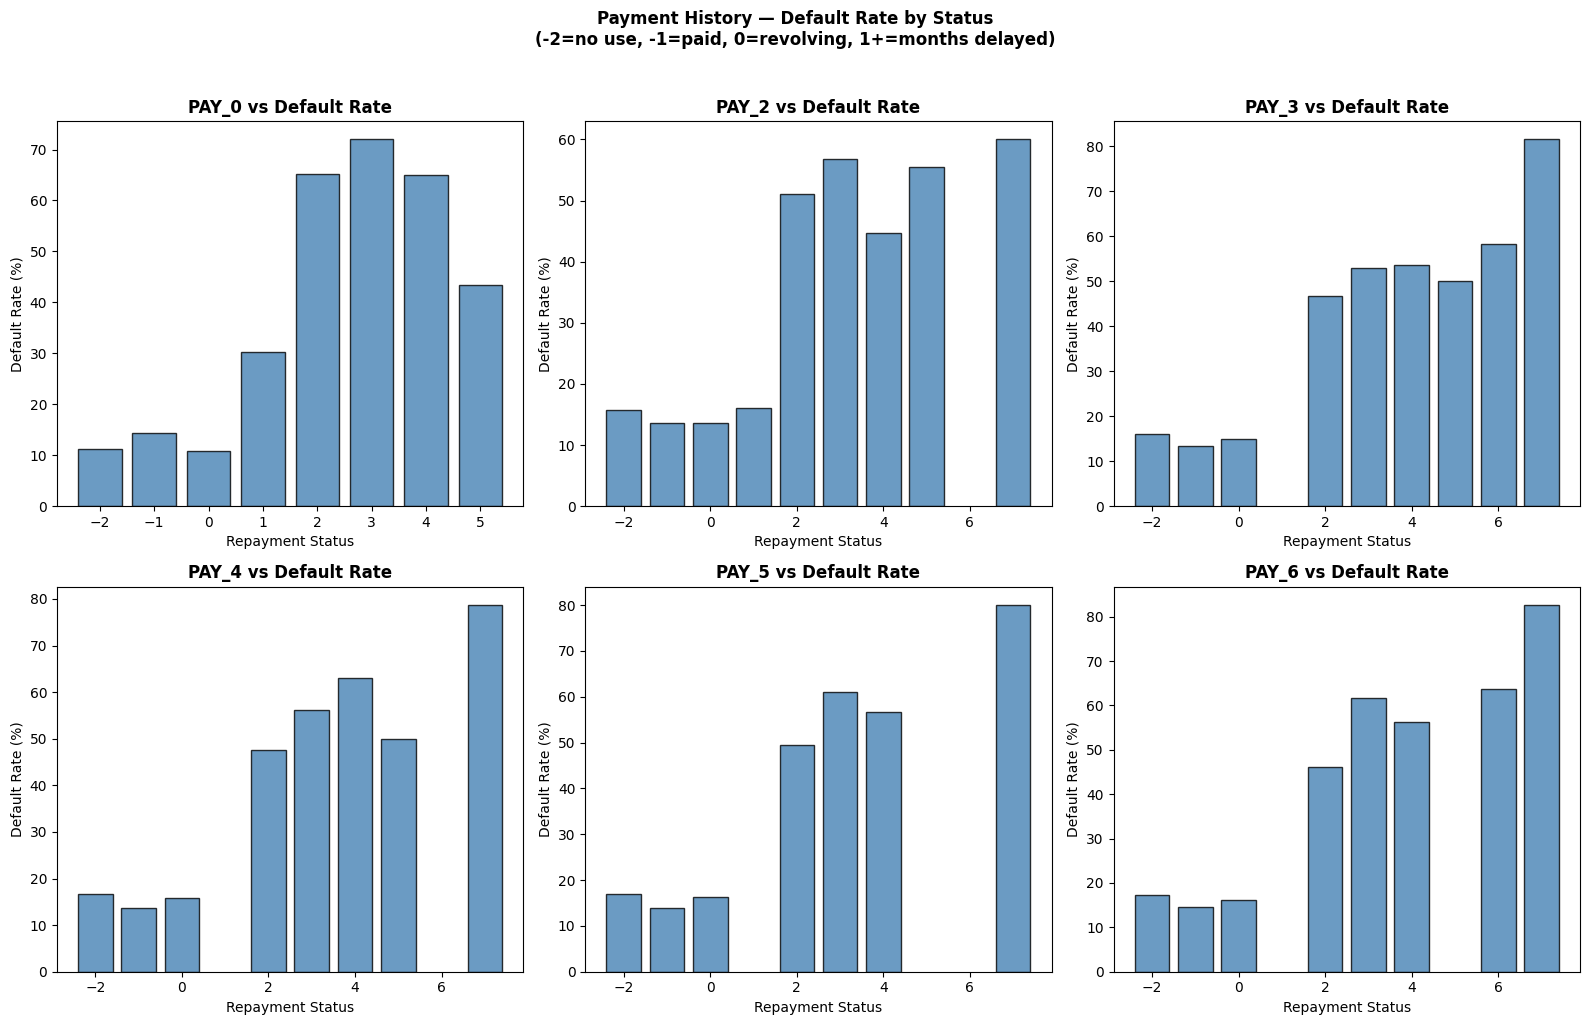

EDA KEY FINDINGS

1. risk_leak (r=0.424) — suspiciously high
   correlation, likely a leakage feature. values > 1 = 100% default.
2. PAY_0 (r=0.314) — most recent payment status
   is the strongest legitimate predictor.
3. RISK_RATING (r=0.362) — pre-assigned
   risk label, might also contain forward-looking info.
4. LIMIT_BAL (r=-0.087) — higher limits
   slightly reduce default probability.
5. BILL_AMT_SUM (r=-0.010) — almost
   zero correlation, not useful on its own.



In [5]:
# correlation analysis
corr_features = ['LIMIT_BAL', 'AGE', 'BILL_AMT_SUM', 'LIMIT_BAL_LOG', 'risk_leak','PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6','BILL_AMT1', 'PAY_AMT1', 'RISK_RATING', tgt]
corr_mat = df[corr_features].corr()

# heatmap
fig, ax = plt.subplots(figsize=(14, 11))
tri_mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
sns.heatmap(corr_mat, mask=tri_mask, annot=True, fmt='.2f', cmap='RdBu_r',center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# which features correlate most with target?
target_corrs = df[corr_features].corr()[tgt].drop(tgt).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
bar_c = ['#c0392b' if v > 0 else '#27ae60' for v in target_corrs.values]
target_corrs.plot(kind='barh', color=bar_c, edgecolor='black', ax=ax)
ax.set_title('Feature Correlation with Default', fontweight='bold', fontsize=13)
ax.set_xlabel('Pearson Correlation')
ax.axvline(0, color='black', lw=0.8)
for i, (v, nm) in enumerate(zip(target_corrs.values, target_corrs.index)):
    offset = 0.01 if v > 0 else -0.01
    align = 'left' if v > 0 else 'right'
    ax.text(v + offset, i, f'{v:.3f}', va='center', ha=align, fontsize=9)
plt.tight_layout()
plt.show()

# payment history deep dive — how PAY_0 to PAY_6 relate to default
pay_features = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for i, col in enumerate(pay_features):
    ax = axes.flatten()[i]
    pay_grp = df.groupby(col)[tgt].agg(['mean', 'count']).reset_index()
    pay_grp = pay_grp[pay_grp['count'] >= 20]  # skip tiny groups
    ax.bar(pay_grp[col], pay_grp['mean']*100, color='steelblue',
           edgecolor='black', alpha=0.8)
    ax.set_title(f'{col} vs Default Rate', fontweight='bold')
    ax.set_xlabel('Repayment Status')
    ax.set_ylabel('Default Rate (%)')
plt.suptitle('Payment History — Default Rate by Status\n(-2=no use, -1=paid, 0=revolving, 1+=months delayed)',fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# quick summary of what we found
print("=" * 60)
print("EDA KEY FINDINGS")
print("=" * 60)
print(f"""
1. risk_leak (r={df['risk_leak'].corr(df[tgt]):.3f}) — suspiciously high
   correlation, likely a leakage feature. values > 1 = 100% default.
2. PAY_0 (r={df['PAY_0'].corr(df[tgt]):.3f}) — most recent payment status
   is the strongest legitimate predictor.
3. RISK_RATING (r={df['RISK_RATING'].corr(df[tgt]):.3f}) — pre-assigned
   risk label, might also contain forward-looking info.
4. LIMIT_BAL (r={df['LIMIT_BAL'].corr(df[tgt]):.3f}) — higher limits
   slightly reduce default probability.
5. BILL_AMT_SUM (r={df['BILL_AMT_SUM'].corr(df[tgt]):.3f}) — almost
   zero correlation, not useful on its own.
""")


categorical encoding
----------------------------------------
Already numeric (no encoding needed):
  sex:        1=Male, 2=Female
  Education:  1=Grad School, 2=University, 3=High School, 0/4/5/6=Other
  Marriagee:   1=Married, 2=Single, 3=Other
  Risk_rating: 1=Low, 2=Medium, 3=High (ordinal)
  PAY_0–PAY_6: -2 to 9 (ordinal — months delayed)

CITY has 50 unique values — using LabelEncoder
  Before: ['City_38', 'City_6', 'City_20']
  After:  [31, 46, 12]

feature Scaling (StandardScaler)
----------------------------------------
Scaling 17 columns

Before scaling (sample):
   LIMIT_BAL   AGE  BILL_AMT_SUM
0    20000.0  24.0        7704.0
1   120000.0  26.0       17077.0
2    90000.0  34.0      101653.0

After scaling (same rows):
   LIMIT_BAL       AGE  BILL_AMT_SUM
0  -0.705605 -1.270344     -0.502119
1  -0.271319 -1.048289     -0.485727
2  -0.401605 -0.160069     -0.337815


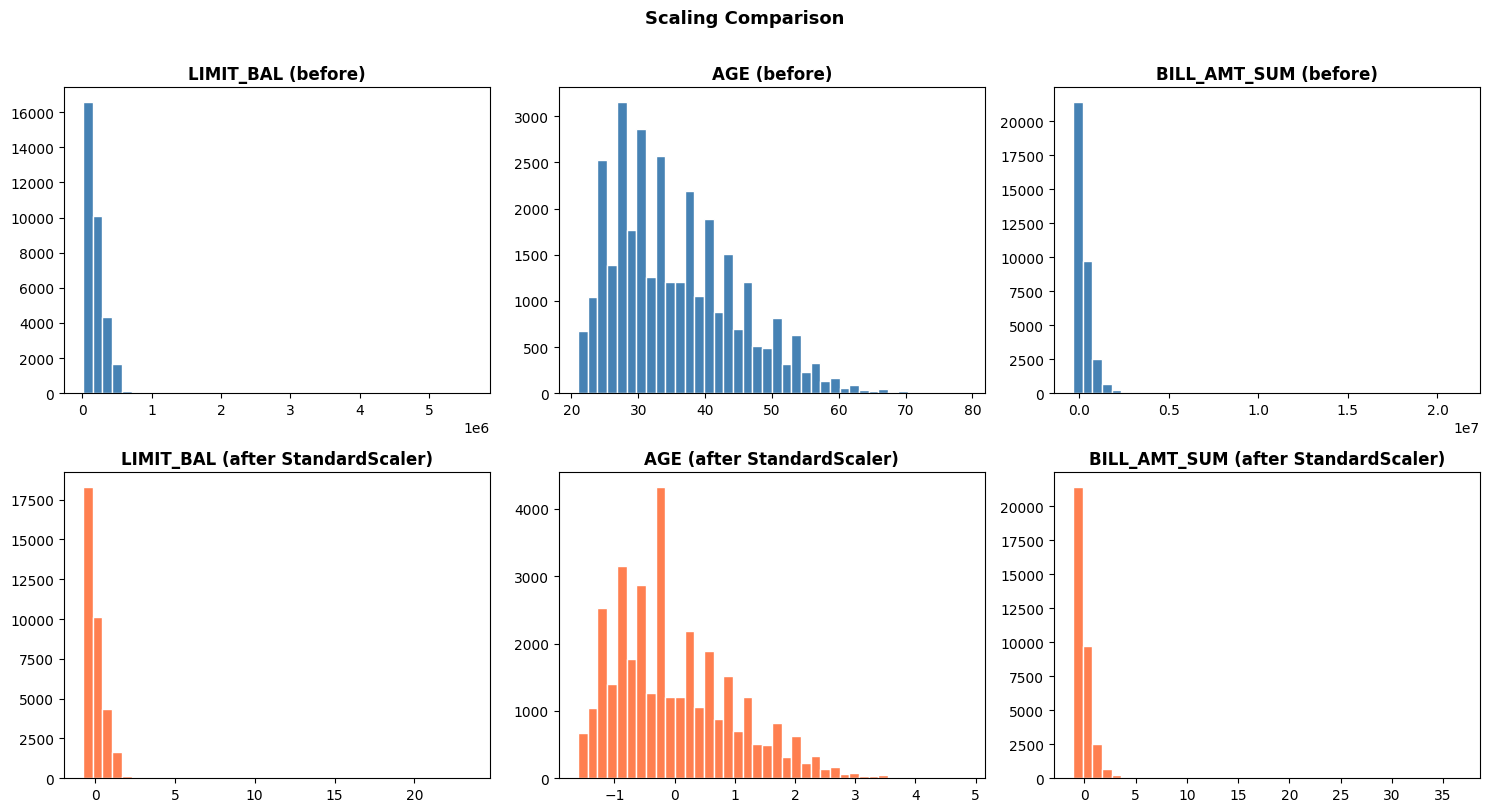


Dataset ready for modelling: (34788, 29)


In [6]:
# Task 2: Categorical Encoding & Feature Scaling

print("categorical encoding")
print("-" * 40)

# Sex, education, marriage, Risk_ratting are already integers — no need to encode
# just documenting what they mean
print("Already numeric (no encoding needed):")
print("  sex:        1=Male, 2=Female")
print("  Education:  1=Grad School, 2=University, 3=High School, 0/4/5/6=Other")
print("  Marriagee:   1=Married, 2=Single, 3=Other")
print("  Risk_rating: 1=Low, 2=Medium, 3=High (ordinal)")
print("  PAY_0–PAY_6: -2 to 9 (ordinal — months delayed)")

# City needs encoding — its string labels like "City_10", "City_36"
print(f"\nCITY has {df['CITY'].nunique()} unique values — using LabelEncoder")
print(f"  Before: {df['CITY'].head(3).tolist()}")
city_encoder = LabelEncoder()
df['CITY'] = city_encoder.fit_transform(df['CITY'])
print(f"  After:  {df['CITY'].head(3).tolist()}")

# Feature scaling with StandardScaler
# standardising numerical columns so they have mean=0, std=1
# this helps models like logistic regression, SVM, KNN that are
# sensitive to feature magnitudes
print(f"\nfeature Scaling (StandardScaler)")
print("-" * 40)

features_to_scale = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
                     'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2',
                     'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
                     'BILL_AMT_SUM', 'LIMIT_BAL_LOG', 'risk_leak']

print(f"Scaling {len(features_to_scale)} columns")
print(f"\nBefore scaling (sample):")
print(df[['LIMIT_BAL', 'AGE', 'BILL_AMT_SUM']].head(3).to_string())

main_scaler = StandardScaler()
df[features_to_scale] = main_scaler.fit_transform(df[features_to_scale])
print(f"\nAfter scaling (same rows):")
print(df[['LIMIT_BAL', 'AGE', 'BILL_AMT_SUM']].head(3).to_string())




# before/after histograms for 3 example features
sample_feats = ['LIMIT_BAL', 'AGE', 'BILL_AMT_SUM']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, feat in enumerate(sample_feats):
    axes[0][i].hist(raw_df[feat].dropna(), bins=40, color='steelblue', edgecolor='white')
    axes[0][i].set_title(f'{feat} (before)', fontweight='bold')
    axes[1][i].hist(df[feat], bins=40, color='coral', edgecolor='white')
    axes[1][i].set_title(f'{feat} (after StandardScaler)', fontweight='bold')
plt.suptitle('Scaling Comparison', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


print(f"\nDataset ready for modelling: {df.shape}")


Train: 27830 samples | Test: 6958 samples

Trainingg set class distribution:
  Non-default: 22505 (80.9%)
  Default:     5325 (19.1%)
  This is imbalanced — models might just predict majority class

Applying SMOTE to training data only...
After SMOTE:
  Non-default: 22505
  Default:     22505
  Now balanced 1:1


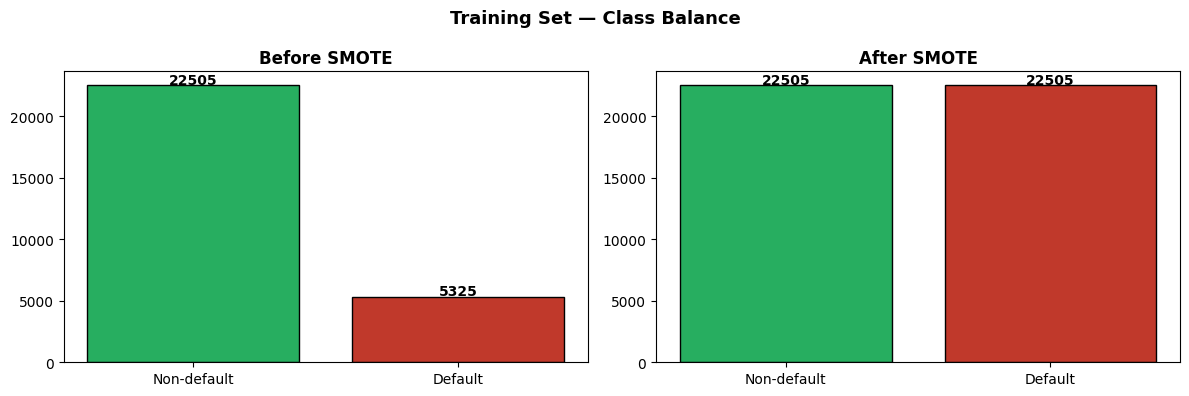

In [7]:
# TaSK 3: Train-Test Split & Handling Class Imbalance

# separating features and target
X_all = df.drop(columns=[tgt])
y_all = df[tgt]

# 80/20 split with stratification to maintain class ratio in both sets
# 80% gives ~28k training samples — enough for learning
# 20% gives ~7k test samples — statistically reliable evaluation
X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.2, random_state=42, stratify=y_all)
print(f"Train: {X_tr.shape[0]} samples | Test: {X_te.shape[0]} samples")

# class distribution in training set
tr_counts = y_tr.value_counts()
print(f"\nTrainingg set class distribution:")
print(f"  Non-default: {tr_counts[0]} ({tr_counts[0]/len(y_tr)*100:.1f}%)")
print(f"  Default:     {tr_counts[1]} ({tr_counts[1]/len(y_tr)*100:.1f}%)")
print(f"  This is imbalanced — models might just predict majority class")

# SMOTE to balance classes — only on training data
# creates synthetic minority samples by interpolating between existing ones
print("\nApplying SMOTE to training data only...")
sm = SMOTE(random_state=42)
X_tr_bal, y_tr_bal = sm.fit_resample(X_tr, y_tr)

bal_counts = pd.Series(y_tr_bal).value_counts()
print(f"After SMOTE:")
print(f"  Non-default: {bal_counts[0]}")
print(f"  Default:     {bal_counts[1]}")
print(f"  Now balanced 1:1")

# visualise the change
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
lbl = ['Non-default', 'Default']
clr = ['#27ae60', '#c0392b']

ax1.bar(lbl, [tr_counts[0], tr_counts[1]], color=clr, edgecolor='black')
for j, v in enumerate([tr_counts[0], tr_counts[1]]):
    ax1.text(j, v+100, str(v), ha='center', fontweight='bold')
ax1.set_title('Before SMOTE', fontweight='bold')

ax2.bar(lbl, [bal_counts[0], bal_counts[1]], color=clr, edgecolor='black')
for j, v in enumerate([bal_counts[0], bal_counts[1]]):
    ax2.text(j, v+100, str(v), ha='center', fontweight='bold')
ax2.set_title('After SMOTE', fontweight='bold')

plt.suptitle('Training Set — Class Balance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [18]:

# TASK 3: Model Training —with risk_leak


all_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Support Vector Machine': SVC(probability=True, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)}

#training with all features including risk_leak
print("=" * 65)
print("model Training —witH risk_leak")
print("=" * 65)
preds_with_leak = {}
res_with_leak = {}

for model_name, model_obj in all_models.items():
    print(f"\nTraining {model_name}...", end=' ')
    t0 = time.time()
    model_obj.fit(X_tr_bal, y_tr_bal)
    elapsed = time.time() - t0


    yp = model_obj.predict(X_te)
    yprob = model_obj.predict_proba(X_te)[:, 1]

    acc = accuracy_score(y_te, yp)
    preds_with_leak[model_name] = {'pred': yp, 'prob': yprob}
    res_with_leak[model_name] = acc


    print(f"Accuracy: {acc:.4f} | Time: {elapsed:.2f}s")

# recording default hyperparameters
print(f"\n{'='*65}")
print("DEFAULT HYPERPARAMETERS")
print(f"{'='*65}")

default_params = {
    'Logistic Regression': 'C=1.0, penalty=l2, solver=lbfgs, max_iter=1000',
    'SVM': 'C=1.0, kernel=rbf, gamma=scale',
    'Decision Tree': 'criterion=gini, max_depth=None, min_samples_split=2',
    'Random Forest': 'n_estimators=100, criterion=gini, max_depth=None',
    'KNN': 'n_neighbors=5, weights=uniform, metric=minkowski',
    'Gradient Boosting': 'n_estimators=100, learning_rate=0.1, max_depth=3'
}
for mn, mp in default_params.items():
    print(f"  {mn}: {mp}")

# several models hit 100% accuracy — this is problamatic
# risk_leak is essentially giving away the answer
print(f"\n problems: Multiple models show 100% accuracy.")
print(f"  This suggests data leakage through the risk_leak feature.")
print(f"  We need to retrain without it for a fair evaluation.")


model Training —witH risk_leak

Training Logistic Regression... Accuracy: 1.0000 | Time: 1.86s

Training Support Vector Machine... Accuracy: 0.8840 | Time: 594.29s

Training Decision Tree... Accuracy: 1.0000 | Time: 0.14s

Training Random Forest... Accuracy: 1.0000 | Time: 8.42s

Training K-Nearest Neighbors... Accuracy: 0.8012 | Time: 0.01s

Training Gradient Boosting... Accuracy: 1.0000 | Time: 17.22s

DEFAULT HYPERPARAMETERS
  Logistic Regression: C=1.0, penalty=l2, solver=lbfgs, max_iter=1000
  SVM: C=1.0, kernel=rbf, gamma=scale
  Decision Tree: criterion=gini, max_depth=None, min_samples_split=2
  Random Forest: n_estimators=100, criterion=gini, max_depth=None
  KNN: n_neighbors=5, weights=uniform, metric=minkowski
  Gradient Boosting: n_estimators=100, learning_rate=0.1, max_depth=3

 problems: Multiple models show 100% accuracy.
  This suggests data leakage through the risk_leak feature.
  We need to retrain without it for a fair evaluation.


In [19]:
# TASK 3: Retrain without risk_leak

print("=" * 65)
print("retraining — WiThout risk_leak ->Leakage Removed")
print("=" * 65)

  #create clean versions of train/test by dropping risk_leak
X_tr_clean = X_tr.drop(columns=['risk_leak'])
X_te_clean = X_te.drop(columns=['risk_leak'])

# need to re-apply SMOTE on clean training data
sm_clean = SMOTE(random_state=42)
X_tr_clean_bal, y_tr_clean_bal = sm_clean.fit_resample(X_tr_clean, y_tr)
print(f"Clean training set (SMOTE): {X_tr_clean_bal.shape}")

# fresh models instances — cant reuse the fitted ones
clean_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Support Vector Machine': SVC(probability=True, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

preds_clean = {}
res_clean = {}
fitted_clean_models = {}


for model_name, model_obj in clean_models.items():
    print(f"Training {model_name} (clean)...", end=' ')
    t0 = time.time()
    model_obj.fit(X_tr_clean_bal, y_tr_clean_bal)
    elapsed = time.time() - t0

    yp = model_obj.predict(X_te_clean)
    yprob = model_obj.predict_proba(X_te_clean)[:, 1]

    acc = accuracy_score(y_te, yp)
    preds_clean[model_name] = {'pred': yp, 'prob': yprob}
    res_clean[model_name] = acc
    fitted_clean_models[model_name] = model_obj

    print(f"Accuracy: {acc:.4f} | Time: {elapsed:.2f}s")

# side-by-side comparison
print(f"\n{'='*65}")
print("COMPARISON: WITH vs WITHOUT risk_leak")
print(f"{'='*65}\n")

comp_data = []
for mn in all_models.keys():
    comp_data.append({
        'Model': mn,
        'With risk_leak': f"{res_with_leak[mn]:.4f}",
        'Without risk_leak': f"{res_clean[mn]:.4f}"
    })
print(pd.DataFrame(comp_data).to_string(index=False))
print("\nRemoving risk_leak drops accuracy to realistic levels.")
print("This confirms it was leaking target information.")


retraining — WiThout risk_leak ->Leakage Removed
Clean training set (SMOTE): (45010, 27)
Training Logistic Regression (clean)... Accuracy: 0.7277 | Time: 2.15s
Training Support Vector Machine (clean)... Accuracy: 0.7850 | Time: 754.95s
Training Decision Tree (clean)... Accuracy: 0.8270 | Time: 1.91s
Training Random Forest (clean)... Accuracy: 0.8646 | Time: 26.11s
Training K-Nearest Neighbors (clean)... Accuracy: 0.7179 | Time: 0.01s
Training Gradient Boosting (clean)... Accuracy: 0.7872 | Time: 38.26s

COMPARISON: WITH vs WITHOUT risk_leak

                 Model With risk_leak Without risk_leak
   Logistic Regression         1.0000            0.7277
Support Vector Machine         0.8840            0.7850
         Decision Tree         1.0000            0.8270
         Random Forest         1.0000            0.8646
   K-Nearest Neighbors         0.8012            0.7179
     Gradient Boosting         1.0000            0.7872

Removing risk_leak drops accuracy to realistic levels.
This

EVALUATION METRICS — WITH risk_leak
                    Model Accuracy Precision  Recall F1-Score AUC-ROC
1     Logistic Regression   1.0000    1.0000  1.0000   1.0000  1.0000
2           Decision Tree   1.0000    1.0000  1.0000   1.0000  1.0000
3       Gradient Boosting   1.0000    1.0000  1.0000   1.0000  1.0000
4           Random Forest   1.0000    1.0000  1.0000   1.0000  1.0000
5  Support Vector Machine   0.8840    0.6885  0.7190   0.7034  0.9548
6     K-Nearest Neighbors   0.8012    0.4856  0.6574   0.5586  0.8092


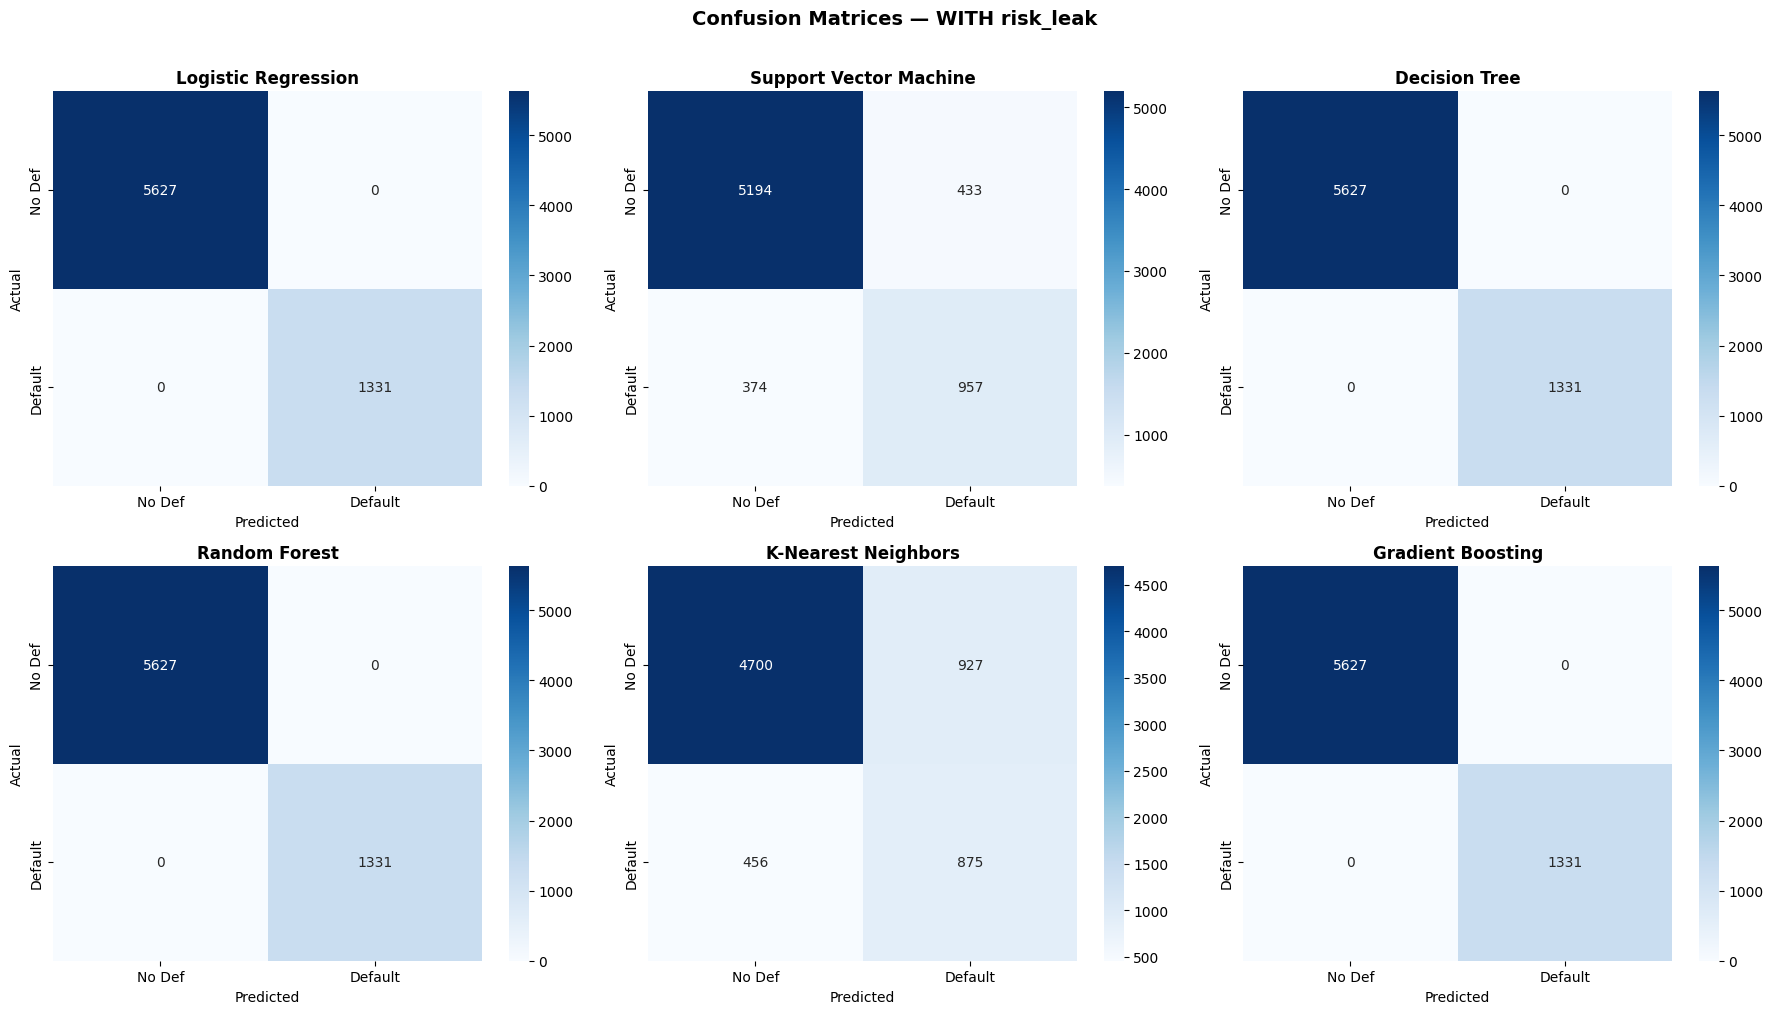


EVALUATION METRICS — WITHOUT risk_leak (Clean)
                    Model Accuracy Precision  Recall F1-Score AUC-ROC
1           Random Forest   0.8646    0.7193  0.4793   0.5753  0.8805
2           Decision Tree   0.8270    0.5548  0.4831   0.5165  0.6957
3  Support Vector Machine   0.7850    0.4495  0.5515   0.4953  0.7458
4       Gradient Boosting   0.7872    0.4518  0.5282   0.4870  0.7499
5     Logistic Regression   0.7277    0.3696  0.6003   0.4575  0.7311
6     K-Nearest Neighbors   0.7179    0.3538  0.5748   0.4380  0.7235

--- Random Forest (Clean) ---
              precision    recall  f1-score   support

  No Default       0.89      0.96      0.92      5627
     Default       0.72      0.48      0.58      1331

    accuracy                           0.86      6958
   macro avg       0.80      0.72      0.75      6958
weighted avg       0.85      0.86      0.85      6958


--- Decision Tree (Clean) ---
              precision    recall  f1-score   support

  No Default      

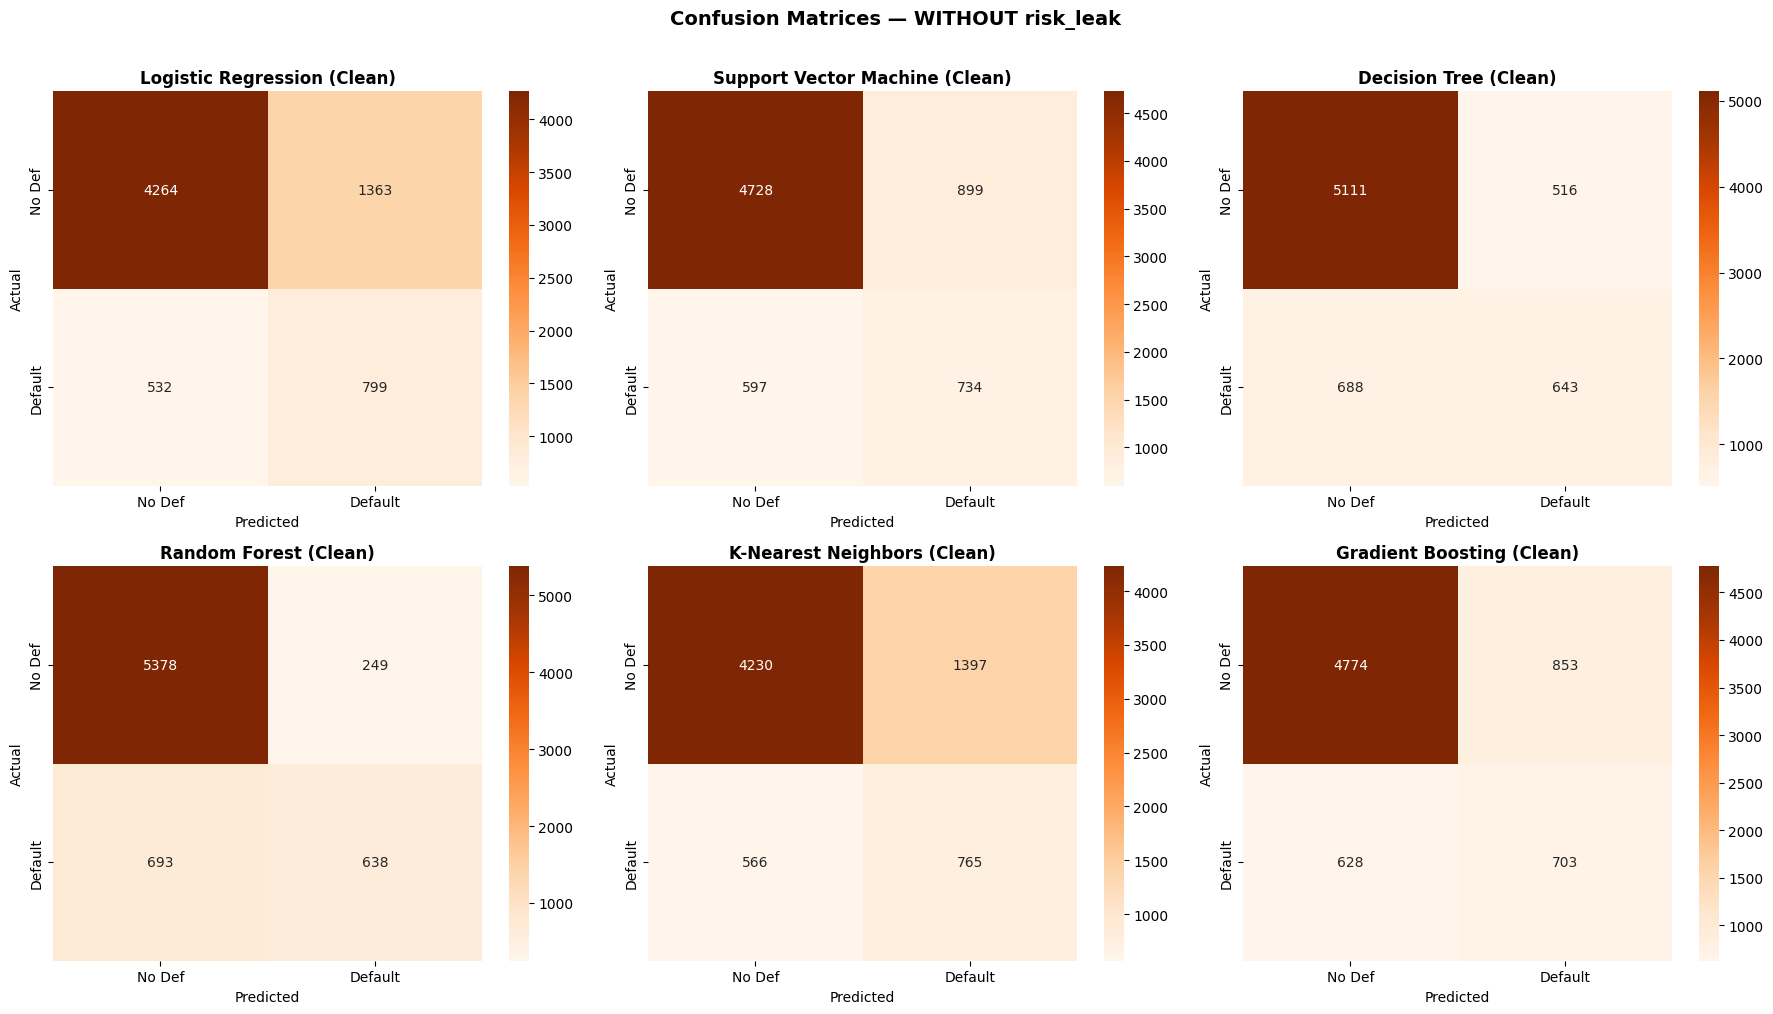

In [21]:


# TASK4: model Evaluation

# full metrics table — WITH risk_leak
print("=" * 75)
print("EVALUATION METRICS — WITH risk_leak")
print("=" * 75)

def calc_metrics(y_true, preds_dict):
    """helper to calculate all metrics for each model"""
    rows = []
    for name in preds_dict:
        yp = preds_dict[name]['pred']
        ypr = preds_dict[name]['prob']
        rows.append({
            'Model': name,
            'Accuracy': accuracy_score(y_true, yp),
            'Precision': precision_score(y_true, yp),
            'Recall': recall_score(y_true, yp),
            'F1-Score': f1_score(y_true, yp),
            'AUC-ROC': roc_auc_score(y_true, ypr)
        })
    result = pd.DataFrame(rows).sort_values('F1-Score', ascending=False)
    result.index = range(1, len(result)+1)
    return result

metrics_leak = calc_metrics(y_te, preds_with_leak)
fmt_leak = metrics_leak.copy()
for c in ['Accuracy','Precision','Recall','F1-Score','AUC-ROC']:
    fmt_leak[c] = fmt_leak[c].apply(lambda x: f"{x:.4f}")
print(fmt_leak.to_string())


    #confusion matrices — with risk_leak
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, mn in enumerate(all_models.keys()):
    cm = confusion_matrix(y_te, preds_with_leak[mn]['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes.flatten()[i],
                xticklabels=['No Def', 'Default'], yticklabels=['No Def', 'Default'])
    axes.flatten()[i].set_title(f'{mn}', fontweight='bold')
    axes.flatten()[i].set_xlabel('Predicted')
    axes.flatten()[i].set_ylabel('Actual')
plt.suptitle('Confusion Matrices — WITH risk_leak', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# same thing WITHOUT risk_leak
print(f"\n{'='*75}")
print("EVALUATION METRICS — WITHOUT risk_leak (Clean)")
print(f"{'='*75}")

metrics_clean = calc_metrics(y_te, preds_clean)
fmt_clean = metrics_clean.copy()
for c in ['Accuracy','Precision','Recall','F1-Score','AUC-ROC']:
    fmt_clean[c] = fmt_clean[c].apply(lambda x: f"{x:.4f}")
print(fmt_clean.to_string())

# classification reports for top 3 clean models
top3_clean = metrics_clean.head(3)['Model'].tolist()
for mn in top3_clean:
    print(f"\n--- {mn} (Clean) ---")
    print(classification_report(y_te, preds_clean[mn]['pred'],
                                target_names=['No Default', 'Default']))

# confusion matrices — without risk_leak
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, mn in enumerate(clean_models.keys()):
    cm = confusion_matrix(y_te, preds_clean[mn]['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes.flatten()[i],
                xticklabels=['No Def', 'Default'], yticklabels=['No Def', 'Default'])
    axes.flatten()[i].set_title(f'{mn} (Clean)', fontweight='bold')
    axes.flatten()[i].set_xlabel('Predicted')
    axes.flatten()[i].set_ylabel('Actual')
plt.suptitle('Confusion Matrices — WITHOUT risk_leak', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


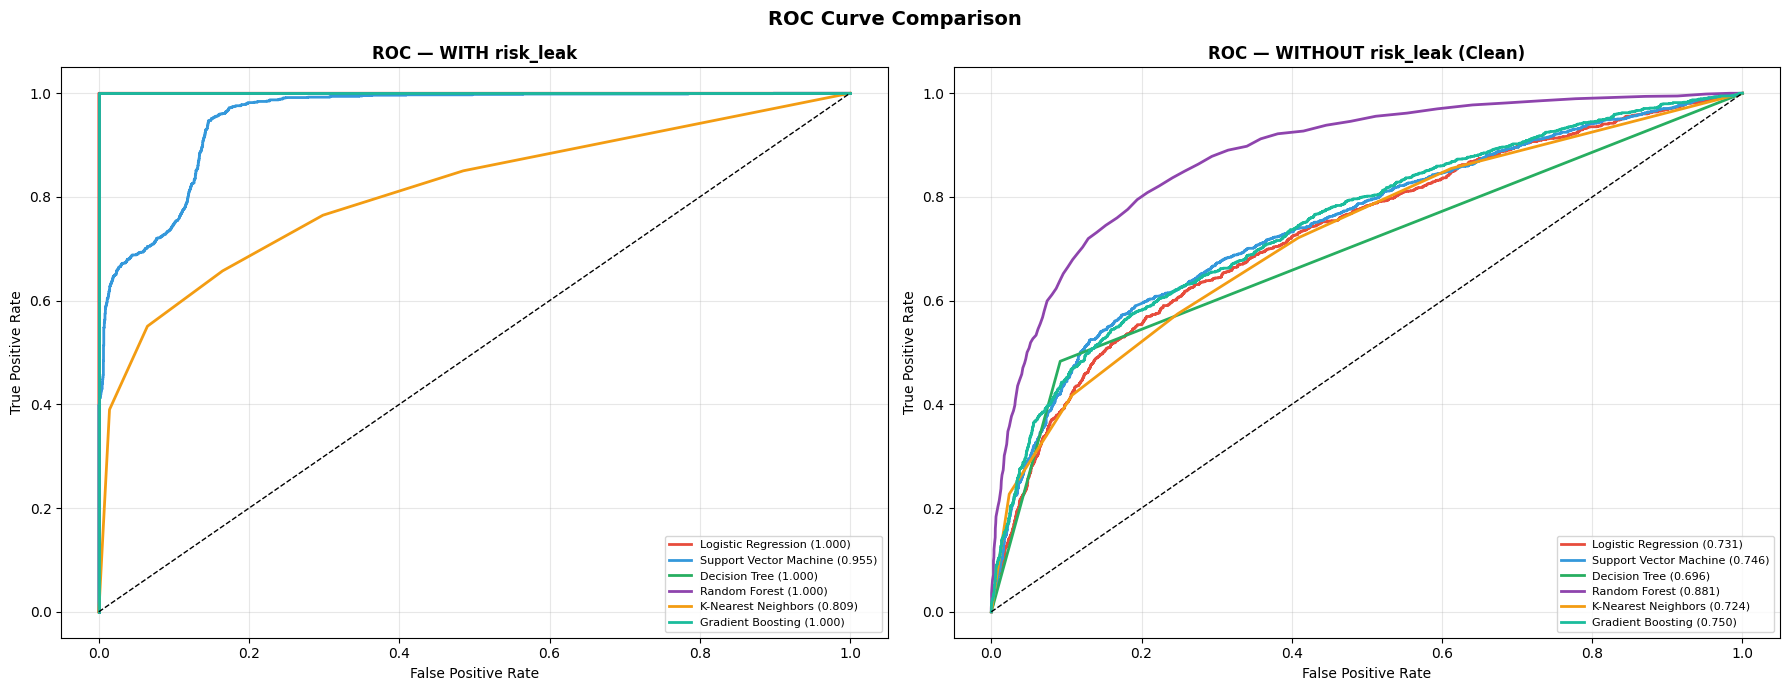

HYPERPARAMETER TUNNING /Clean Data — No Leakage

[1/2] Tuning Random Forest...
  Best params: {'max_depth': None, 'n_estimators': 200}
  Best CV F1:  0.8286

[2/2] Tuning Gradient Boosting...
  Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
  Best CV F1:  0.7897

BEFORE vs AFTER TUNING (Clean Data)

                      Model Accuracy Precision Recall F1-Score AUC-ROC
    Random Forest (Default)   0.8646    0.7193 0.4793   0.5753  0.8805
Gradient Boosting (Default)   0.7872    0.4518 0.5282   0.4870  0.7499
      Random Forest (Tuned)   0.8650    0.7237 0.4763   0.5745  0.8849
  Gradient Boosting (Tuned)   0.8175    0.5257 0.4681   0.4952  0.7601


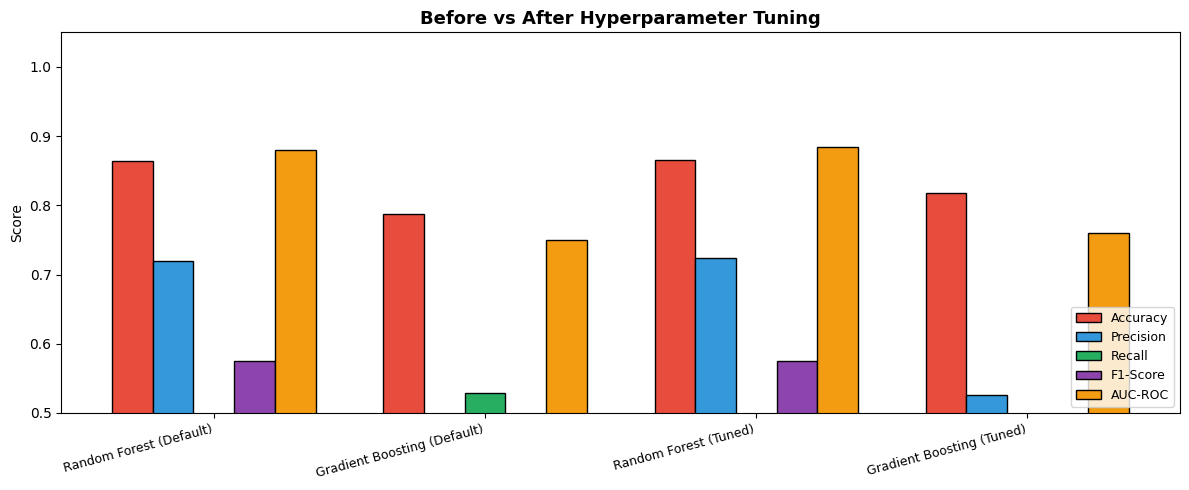

In [22]:
# ROC curves — both versions

# with risk_leak
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
plot_colors = ['#e74c3c', '#3498db', '#27ae60', '#8e44ad', '#f39c12', '#1abc9c']

for i, mn in enumerate(all_models.keys()):
    fpr, tpr, _ = roc_curve(y_te, preds_with_leak[mn]['prob'])
    auc_val = roc_auc_score(y_te, preds_with_leak[mn]['prob'])

    ax1.plot(fpr, tpr, color=plot_colors[i], lw=2, label=f'{mn} ({auc_val:.3f})')
ax1.plot([0,1], [0,1], 'k--', lw=1)
ax1.set_title('ROC — WITH risk_leak', fontweight='bold', fontsize=12)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')

ax1.legend(fontsize=8, loc='lower right')
ax1.grid(alpha=0.3)



for i, mn in enumerate(clean_models.keys()):
    fpr, tpr, _ = roc_curve(y_te, preds_clean[mn]['prob'])
    auc_val = roc_auc_score(y_te, preds_clean[mn]['prob'])
    ax2.plot(fpr, tpr, color=plot_colors[i], lw=2, label=f'{mn} ({auc_val:.3f})')
ax2.plot([0,1], [0,1], 'k--', lw=1)
ax2.set_title('ROC — WITHOUT risk_leak (Clean)', fontweight='bold', fontsize=12)
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.legend(fontsize=8, loc='lower right')
ax2.grid(alpha=0.3)

plt.suptitle('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

          # Hyperparameter Tuning on CLEAN models (without risk_leak)
        #tuning the top 2 performers: Random Forest and Gradient Boosting


print("=" * 65)
print("HYPERPARAMETER TUNNING /Clean Data — No Leakage")
print("=" * 65)



# Random Forest — GridSearchCV
print("\n[1/2] Tuning Random Forest...")
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, None],
}
rf_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid, cv=2, scoring='f1', n_jobs=-1
)
rf_search.fit(X_tr_clean_bal, y_tr_clean_bal)
print(f"  Best params: {rf_search.best_params_}")
print(f"  Best CV F1:  {rf_search.best_score_:.4f}")

# Gradient Boosting — RandomizedSearchCV (faster)
print("\n[2/2] Tuning Gradient Boosting...")
gb_param_dist = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'max_depth': [3, 5],
}
gb_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_param_dist, cv=2, scoring='f1', n_jobs=-1
)
gb_search.fit(X_tr_clean_bal, y_tr_clean_bal)
print(f"  Best params: {gb_search.best_params_}")
print(f"  Best CV F1:  {gb_search.best_score_:.4f}")

# before vs after tuning comparisons
print(f"\n{'='*65}")
print("BEFORE vs AFTER TUNING (Clean Data)")
print(f"{'='*65}\n")

tuning_comparison = []
# default models
for mn in ['Random Forest', 'Gradient Boosting']:
    yp = preds_clean[mn]['pred']
    ypr = preds_clean[mn]['prob']
    tuning_comparison.append({
        'Model': f'{mn} (Default)',
        'Accuracy': accuracy_score(y_te, yp),
        'Precision': precision_score(y_te, yp),
        'Recall': recall_score(y_te, yp),
        'F1-Score': f1_score(y_te, yp),
        'AUC-ROC': roc_auc_score(y_te, ypr)
    })

# tuned models
tuned_dict = {
    'Random Forest (Tuned)': rf_search.best_estimator_,
    'Gradient Boosting (Tuned)': gb_search.best_estimator_
}
for mn, mdl in tuned_dict.items():
    yp_t = mdl.predict(X_te_clean)
    ypr_t = mdl.predict_proba(X_te_clean)[:, 1]
    tuning_comparison.append({
        'Model': mn,
        'Accuracy': accuracy_score(y_te, yp_t),
        'Precision': precision_score(y_te, yp_t),
        'Recall': recall_score(y_te, yp_t),
        'F1-Score': f1_score(y_te, yp_t),
        'AUC-ROC': roc_auc_score(y_te, ypr_t)
    })

tune_df = pd.DataFrame(tuning_comparison)
tune_display = tune_df.copy()
for c in ['Accuracy','Precision','Recall','F1-Score','AUC-ROC']:
    tune_display[c] = tune_display[c].apply(lambda x: f"{x:.4f}")
print(tune_display.to_string(index=False))

# visual comparison
fig, ax = plt.subplots(figsize=(12, 5))
x_pos = np.arange(len(tune_df))
w = 0.15
for i, metric in enumerate(['Accuracy','Precision','Recall','F1-Score','AUC-ROC']):
    ax.bar(x_pos + i*w, tune_df[metric], w, label=metric,
           color=plot_colors[i], edgecolor='black')
ax.set_xticks(x_pos + w*2)
ax.set_xticklabels(tune_df['Model'], rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Score')
ax.set_title('Before vs After Hyperparameter Tuning', fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
ax.set_ylim(0.5, 1.05)
plt.tight_layout()
plt.show()


SHAP ANALYSIS — Best Model Clean, No Leakage
Best model: Random Forest (Default)
Computing SHAP values — might take a minute or two...

[1/3] Global Feature Importance


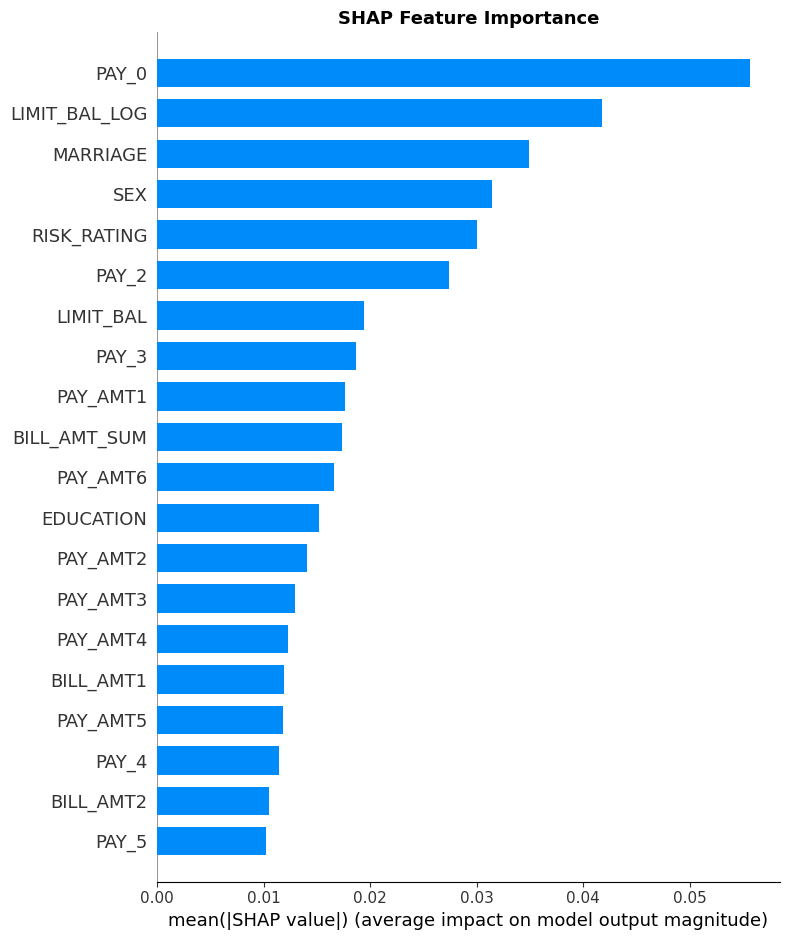

[2/3] Beeswarm Plot — Impact Direction


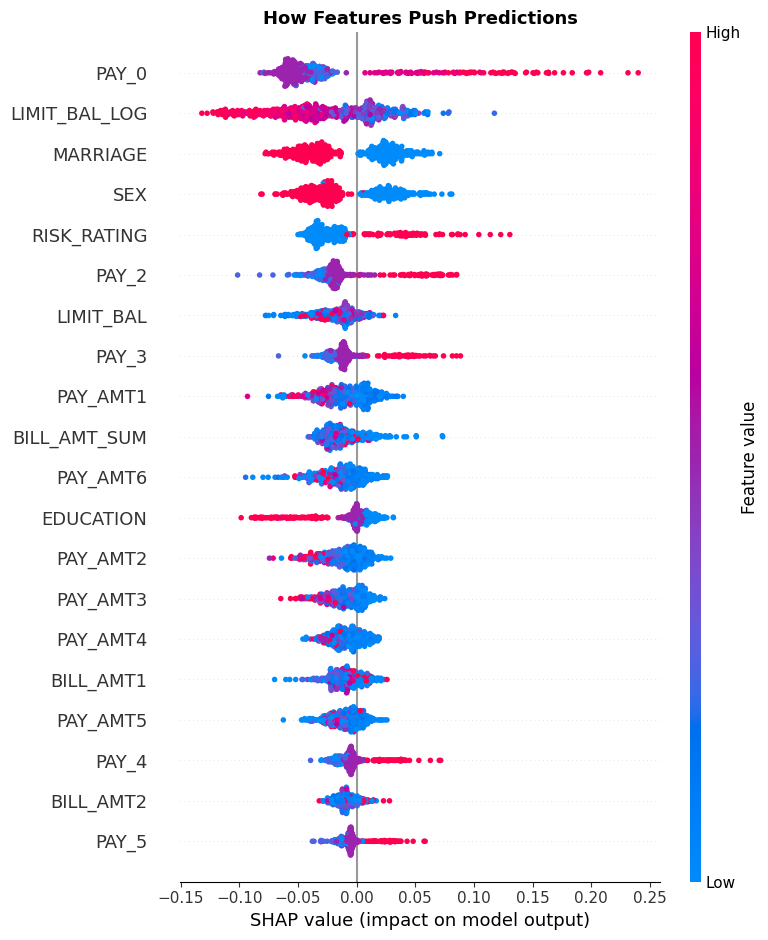

[3/3] Dependence PlotS — Key features


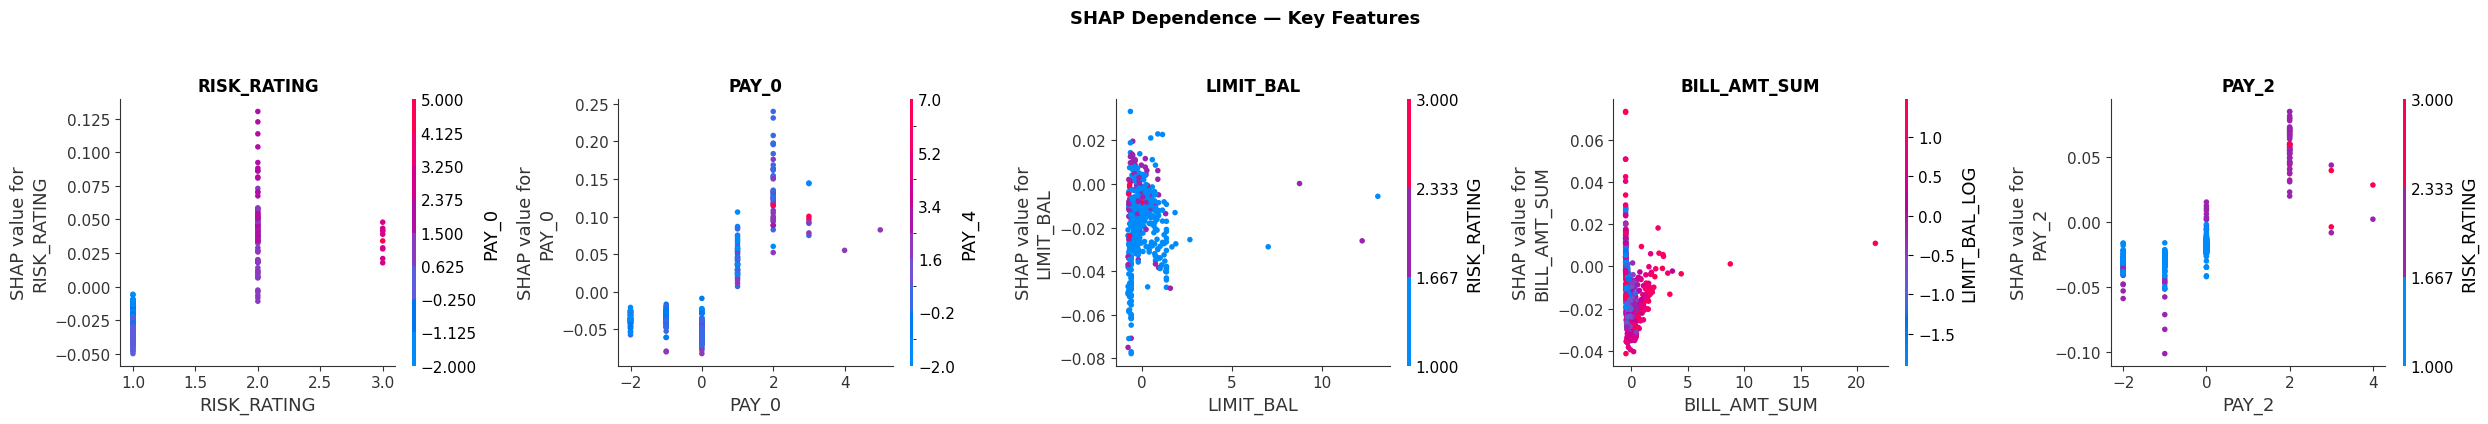


Top 10 Features by SHAP Importance:
      Feature  Mean |SHAP|
        PAY_0     0.055713
LIMIT_BAL_LOG     0.041801
     MARRIAGE     0.034922
          SEX     0.031481
  RISK_RATING     0.030046
        PAY_2     0.027375
    LIMIT_BAL     0.019403
        PAY_3     0.018635
     PAY_AMT1     0.017656
 BILL_AMT_SUM     0.017368


In [23]:

# TASK 4: SHAP Model

print("=" * 65)
print("SHAP ANALYSIS — Best Model Clean, No Leakage")
print("=" * 65)

# pick the best tuned model based on f1
best_f1_idx = tune_df['F1-Score'].idxmax()
best_label = tune_df.loc[best_f1_idx, 'Model']
if 'Random Forest' in best_label:
    best_mdl = rf_search.best_estimator_
else:
    best_mdl = gb_search.best_estimator_
print(f"Best model: {best_label}")

# SHAP on a sample of test data (500 points for speed)
print("Computing SHAP values — might take a minute or two...")
shap_sample = X_te_clean.sample(500, random_state=42)
tree_explainer = shap.TreeExplainer(best_mdl)
sv = tree_explainer.shap_values(shap_sample)

# handle differennt shap output format
if isinstance(sv, list):
    shap_v = sv[1]  # positive class
elif len(sv.shape) == 3:
    shap_v = sv[:, :, 1]
else:
    shap_v = sv

# 1feature importance bar plot
print("\n[1/3] Global Feature Importance")
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_v, shap_sample, plot_type='bar', show=False)
plt.title('SHAP Feature Importance', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

#2. beeswarm plot — shows directions of impact
print("[2/3] Beeswarm Plot — Impact Direction")
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_v, shap_sample, show=False)
plt.title('How Features Push Predictions', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# 3 dependence plots for key features
print("[3/3] Dependence PlotS — Key features")
key_feats = ['RISK_RATING', 'PAY_0', 'LIMIT_BAL', 'BILL_AMT_SUM', 'PAY_2']
fig, axes = plt.subplots(1, 5, figsize=(25, 4))
for i, feat in enumerate(key_feats):
    if feat in shap_sample.columns:
        shap.dependence_plot(feat, shap_v, shap_sample, ax=axes[i], show=False)
        axes[i].set_title(feat, fontweight='bold')
plt.suptitle('SHAP Dependence — Key Features', fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# feature importance ranking
avg_shap = pd.DataFrame({
    'Feature': shap_sample.columns,
    'Mean |SHAP|': np.abs(shap_v).mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=False)

print(f"\nTop 10 Features by SHAP Importance:")
print(avg_shap.head(10).to_string(index=False))
